# The Bowman-2018 pipeline: single-day analysis

This notebook performs the single-day parts of the analysis pipeline that matches the Bowman+2018 results, using the python `edges-collab` stack. This loads in a full day of data, flags out bad integrations, flags RFI, and averages all retained LSTs.

In [10]:
# PARAMETER CELL
# All parameters set here can be over-written by papermill (and therefore nextflow)
# via the command-line invocation. 

alan_output_dir: str = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/"
outdir: str = "."

datafile: str = "/data7/smurray/edges/b18-raw-gsh5-cache/edges-low-alan-fast/2016-250.gsh5"

# Note that adcmax is different from Alan's pipeline which sets adcmax=0.40
# The reason for this is that Alan uses the ADC reading on the data-line
# of the .acq files, which seems to be the adcmax value from the metadata
# line, but rounded to the nearest tenth. The 0.35 here is applied to the
# un-rounded adcmax value, and therefore corresponds to the same meaning
# as 0.40 in Alan's pipeline.
do_aux_filter: bool = True
aux_filter_params: dict = {
    'minima': {},
    'maxima': {
        'adcmax': 0.35  
    }
}

lst_min: float = 6.0
lst_max: float = 18.0
use_alan_coordinates: bool = True

do_power_percent_filter: bool = True
power_percent_params = {
    'min_threshold': 0.7,
    'max_threshold': 3
}

do_peak_orbcomm_filter: bool = True
peak_orbcomm_params = {
    'threshold': 40.0
}

do_maxfm_filter: bool = True
maxfm_filter_params = {
    'threshold': 200.0
}

do_rmsf_filter: bool = True
rmsf_filter_params = {
    'freq_range': [60., 80.],
    'threshold': 200.0
}

gauss_smooth_params = {
    "size": 8,
    'decimate_at': 0,
    'maintain_flags': 1,
    'flag_threshold': 0.25,
    'use_nsamples': True,
}

do_balun_connector_loss: bool = True
do_antenna_loss: bool = False
do_ground_loss: bool = False
do_beam_correction: bool = False  # should be True to match B18      

first_freqcut_min: float = 40.0  # MHz
first_freqcut_max: float = 100.0  # MHz

inject_flags: bool = False

## Imports and Versions

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from importlib.metadata import version
from copy import deepcopy
import sys 

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from astropy.coordinates import Longitude
import pandas as pd
import yaml

from pygsdata import plots, GSData, GSFlag
from pygsdata.select import select_freqs, select_lsts, lst_selector

from edges.cal import Calibrator
from edges.alanmode import read_specal, read_spec_txt
from edges import modeling as mdl
from edges.cal.dicke import dicke_calibration

from edges.cal.apply import approximate_temperature
from edges.const import KNOWN_TELESCOPES
from edges.averaging.freqbin import gauss_smooth
from edges.averaging import average_over_times, NsamplesStrategy
from edges.filters import filters
from pygsdata.coordinates import gha2lst
from edges_pipeline_utils import utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
utils.print_versions()

Versions: 
            read_acq: 1.2.0
            pygsdata: 0.2.3
      edges-analysis: 8.2.0


In [13]:
FLAGGING_INFO = {}

## Load Data

In [14]:
outdir = Path(outdir)
outdir.mkdir(exist_ok=True, parents=True)

In [15]:
data = GSData.from_file(datafile)

In [16]:
obsname = data.name

In [17]:
year, day = tuple(map(int, obsname.split("-")))

In [18]:
alan_output_dir = Path(alan_output_dir) / str(utils.yday_to_alanday(year, day))

In [19]:
print(f"In this notebook, we are averaging data on day {obsname}, corresponding to Alan's numbering: {alan_output_dir.name}")

In this notebook, we are averaging data on day 2016-250, corresponding to Alan's numbering: 616


In [20]:
print(f"Number of integrations in the data: {data.ntimes}")

Number of integrations in the data: 1946


In [21]:
FLAGGING_INFO['Total Times'] = data.ntimes

## Multi-Integration Data Workflow

### Select LSTs

In [22]:
mask = lst_selector(data.lsts, data.loads, load='all', lst_range=[lst_min, lst_max], gha=True)

In [23]:
time_flags_alan = np.genfromtxt(alan_output_dir/"time_flags.txt", names=True)

In [24]:
if len(time_flags_alan) == len(mask)+1:
    # Very rarely, an ACQ spectrum file is truncated on the last line (i.e. does not have all its spectra)
    # In this case, read_acq discards the line (and full 3-position switch cycle) entirely, while the C-code
    # reads it in and creates a time-flag entry. We ensure that this extra cycle is indeed flagged, and then
    # ignore it
    any_flagged = any(time_flags_alan[-1][name]<0 for name in time_flags_alan.dtype.names if not name.startswith("HA"))
    assert any_flagged
    
    time_flags_alan = time_flags_alan[:-1]

In [25]:
alan_gha_mask = time_flags_alan['gha0'].astype(bool) & time_flags_alan['gha1'].astype(bool) & time_flags_alan['gha2'].astype(bool)

In [26]:
# Check that our selected LSTs exactly match Alan's
assert np.sum(alan_gha_mask ^ mask) == 0

In [27]:
data = select_lsts(data, lst_range=[lst_min, lst_max], gha=True, load='all')  # need to re-implement use_alan_coordinates...

In [28]:
FLAGGING_INFO['LST Selection'] = data.ntimes

In [29]:
if data.ntimes == 0:
    print("There are no LSTs in the range on this day! Exiting")
    if np.any(alan_gha_mask):
        raise AssertionError("THe C-code picked up some LSTs, but this notebook didn't!")
    else:
        sys.exit(0)

In [30]:
print(data.lsts.min(), data.lsts.max())

0h00m11.21697144s 23h59m57.17864072s


In [31]:
print(f"New minimum and maximum GHA: {data.gha.min()} -- {data.gha.max()}")

New minimum and maximum GHA: 6.009091133117948 hourangle -- 17.989606059586407 hourangle


In [32]:
print(f"New number of integrations: {data.ntimes}")

New number of integrations: 845


### Flag out bad integrations

In [33]:
if do_aux_filter:
    data = filters.aux_filter(data, **aux_filter_params)

In [34]:
if do_power_percent_filter:
    data = filters.power_percent_filter(data, **power_percent_params)

### Dicke-Switch Calibration and Approximating Temperature

In [35]:
data = dicke_calibration(data)

In [36]:
data = approximate_temperature(data, tload=300, tns=1000)

### More Integration Filters

In [37]:
if do_peak_orbcomm_filter:
    data = filters.peak_orbcomm_filter(data, **peak_orbcomm_params)

In [38]:
if do_maxfm_filter:
    data = filters.maxfm_filter(data, **maxfm_filter_params)

In [39]:
if do_rmsf_filter:
    data = filters.rmsf_filter(data, **rmsf_filter_params)

/data7/smurray/edges/edges-analysis/.venv/lib/python3.11/site-packages/pygsdata/select.py:77: UserWarning: frequency range given without units, assuming MHz.
  mask = freq_selector(data.freqs, freq_range=freq_range, indx=indx)


In [40]:
plots.plot_waterfall(data, vmin= 0, vmax=1.2e4);

In [41]:
# Get the number of flags in Alan's file for each filter
tf_alan = time_flags_alan[alan_gha_mask]

aux_mask = tf_alan['adc0'].astype(bool) & tf_alan['adc1'].astype(bool) & tf_alan['adc2'].astype(bool)
alan_flags = {
    'aux': ~aux_mask,
    'power_percent': tf_alan['ppercent'][aux_mask] <= 0,
    'peak_orbcomm': tf_alan['pkpower'][aux_mask] <= 0,
    'maxfm': tf_alan['fmpwr'][aux_mask] <= 0,
    'rmsf': tf_alan['rmsf'][aux_mask] <= 0,
}

In [42]:
table = []
for name, flg in data.flags.items():
    key = name.replace("_filter", "")
    ea_flags = flg.full_rank_flags[0,0,:,0]
    
    entry = {
        'name': key, 
        '# flags': np.sum(ea_flags), 
        '# flags (C)': np.sum(alan_flags[key]),
        '# differing flags': np.sum(ea_flags[aux_mask] ^ alan_flags[key]) if key!='aux' else np.sum(ea_flags ^ alan_flags[key]),
        "% flagged": 100*np.sum(flg.full_rank_flags[0,0,:,0])/flg.full_rank_flags.shape[2]
    }
    table.append(entry)
    FLAGGING_INFO[name] = int(np.sum(ea_flags))
    
ea_complete = data.complete_flags[0,0,:, 0]
ccode_complete = np.any([tf_alan[key] <= 0 for key in ['ppercent', 'pkpower', 'd150', 'dloadmax', 'rmsf', 'fmpwr']], axis=0)

table.append({
    "name": "TOTAL (w/ overlapping)", 
    "# flags": np.sum(ea_complete), 
    "% flagged": 100*np.sum(ea_complete)/data.ntimes,
    "# flags (C)": np.sum(ccode_complete),
    "# differing flags": np.sum(ea_complete ^ ccode_complete),
    })
table = pd.DataFrame(table)
table = table.set_index('name')
FLAGGING_INFO['total'] = int(np.sum(ea_complete))

def highlight_differing(s):
    return np.where(s > 0, 'background-color:orange;', 'background-color:green;')

slice_ = ["# differing flags"]
table.style.apply(highlight_differing, axis=0, subset=slice_)

,# flags,# flags (C),# differing flags,% flagged
name,,,,
aux,30,30,0,3.550296
power_percent,19,4,0,2.248521
peak_orbcomm,0,0,0,0.000000
maxfm,303,277,0,35.857988
rmsf,0,129,129,0.000000
TOTAL (w/ overlapping),307,307,0,36.331361


In [43]:
# Actually create an error if the total differing flags is non-zero
assert table.loc['TOTAL (w/ overlapping)']['# differing flags']==0

In [44]:
# Exit early if there's no data left.
if np.sum(~data.complete_flags)==0:
    sys.exit(0)

In [45]:
# Save the flags
np.savez(outdir / f"{obsname}.integration-flags.npz", **{name: data.flags[name].flags for name in data.flags})

### Average Over LSTs

In [46]:
# Save out a list of LSTs used in the data (unflagged) in case we want to use these for later beam-factor calculations.
np.savetxt(f"{obsname}.lsts.txt", data.lsts.hourangle)

In [47]:
lstbin_data = average_over_times(
    data, use_resids=False, reference_lst=gha2lst(Longitude(0.5*(lst_max + lst_min)*un.hourangle)), nsamples_strategy=NsamplesStrategy.FLAGGED_NSAMPLES_UNIFORM
)

/data7/smurray/edges/edges-analysis/src/edges/averaging/lstbin.py:105: RuntimeWarning: invalid value encountered in multiply
  sum_data = np.nansum(data.data * w, axis=-2)
/data7/smurray/edges/edges-analysis/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/data7/smurray/edges/edges-analysis/src/edges/averaging/lstbin.py:106: RuntimeWarning: invalid value encountered in divide
  new_data = sum_data / ntot


In [48]:
data = select_freqs(lstbin_data, freq_range=[first_freqcut_min*un.MHz, first_freqcut_max*un.MHz])
pre_rfi_data = deepcopy(data)

In [49]:
utils.plot_single_spectrum(data)

## Single-LST-Bin Workflow

### RFI Excision

In [50]:
pre_rfi_file = (outdir/ obsname).with_suffix('.pre-rfi.gsh5')
try:
    pre_rfi_data.write_gsh5(pre_rfi_file);
except NameError:
    pre_rfi_data = GSData.from_file(pre_rfi_file)

In [51]:
alan_rfi_flags = ~np.genfromtxt(alan_output_dir/"rfi_flags.txt").astype(bool)

In [52]:
pre_rfi_data.data.shape

(1, 1, 1, 9831)

In [54]:
9831//16

614

In [53]:
if inject_flags:
    rfiflg = GSFlag(alan_rfi_flags[-1], axes=('freq',))
    data = pre_rfi_data.add_flags('injected-rfi', rfiflg, append_to_file=False)
else:
    data = filters.rfi_iterative_sliding_window(
        pre_rfi_data,
        model = mdl.Fourier(n_terms=37, period=1.5, transform=mdl.ZerotooneTransform(
            range=(
                data.freqs.min().to_value("MHz"), 
                data.freqs.max().to_value("MHz"),
            )
        )),
        max_iter=100,
        reflag_thresh=0,
        fit_kwargs = {"method": 'alan-qrd'},
        window_frac = 16,
        min_window_size = 10,
        threshold = 2.5,
        #reflag_thresh = 1.0,
        watershed = {
            1.0: 4,
            10.0: 8,
            100.0: 16
        },
        n_threads=1
    )

In [57]:
print(f"{data.complete_flags.sum()}/{data.nfreqs} channels flagged during xrfi")

468/9831 channels flagged during xrfi


In [ ]:
FLAGGING_INFO['xrfi'] = int(data.complete_flags.sum())

In [ ]:
with open(outdir / f"{obsname}.flag-info.yaml", 'w') as _fl:
    yaml.dump(FLAGGING_INFO, _fl)

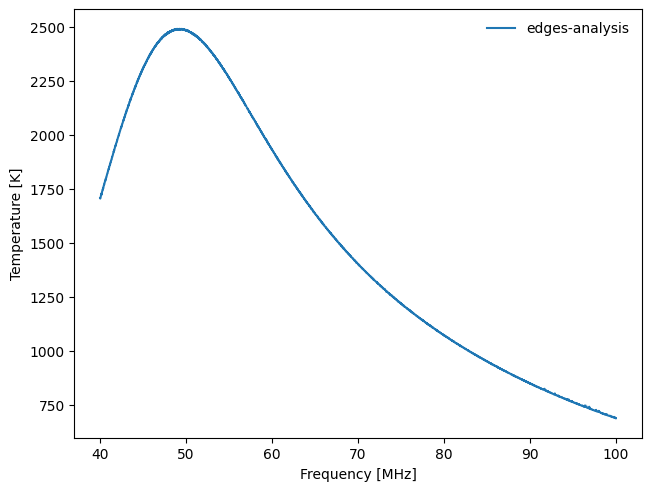

In [58]:
utils.plot_single_spectrum(data)

In [ ]:
data.write_gsh5(outdir / f"{obsname}.unsmoothed.averaged.gsh5")

### Smooth Over Frequency

In [59]:
pre_smooth_data = deepcopy(data)

In [60]:
data = gauss_smooth(data, **gauss_smooth_params)

In [61]:
# After smoothing, any flags over the frequency axis are removed, but nsamples is maintained correctly.
ourflags = data.nsamples[0,0,0] == 0

In [62]:
pre_cal_data = deepcopy(data)

In [63]:
alan_avg = read_spec_txt(alan_output_dir/"spegva.txt")

In [64]:
ndiff_flags =  np.sum(~ourflags ^ (alan_avg.nsamples>0))
if inject_flags:
    assert ndiff_flags == 0
else:
    print("Number of differing flags: ", ndiff_flags)
    print("Number of flags in edges-analysis: ", np.sum(ourflags))
    print("Number from Alan's code: ", np.sum(alan_avg.nsamples==0))

Number of differing flags:  115
Number of flags in edges-analysis:  58
Number from Alan's code:  167


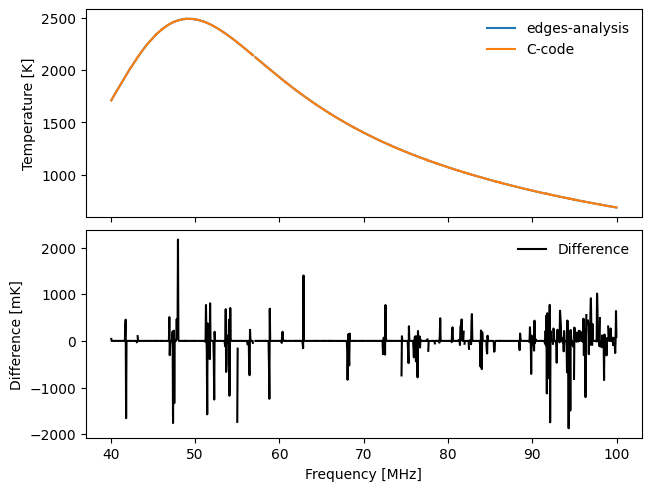

In [65]:
utils.plot_single_spectrum(pre_cal_data, alan_avg.data.squeeze())

In [66]:
outfile = outdir / f"{obsname}.averaged.gsh5"

PosixPath('2016-250.averaged.gsh5')

In [67]:
pre_cal_data.write_gsh5(outfile);
print(f"Wrote {outfile}")

ValueError: group / in file 2016-250.averaged.gsh5 already exists!